# Hash vs genetic demultiplexing assignments

Compare the assignments between the two methods as a sanity check on the results.

In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [196]:
# Choose which pool to visualize
pool = 8


## Load data

In [197]:
cwd = os.getcwd()


In [198]:
gex_file = cwd + f"/vireo/pool{pool}/donor_ids.tsv"
gex_df = pd.read_csv(gex_file, delimiter="\t")


In [199]:
gex_df.head()


,cell,donor_id,prob_max,prob_doublet,n_vars,best_singlet,best_doublet,doublet_logLikRatio
0,AAACCCAAGCCTTGAT-1,donor0,1.000000e+00,7.380000e-112,2284,donor0,"donor0,donor3",-252.937
1,AAACCCACAAGTCCCG-1,donor3,1.000000e+00,5.090000e-220,2181,donor3,"donor1,donor2",-501.987
2,AAACCCACATAACGGG-1,donor3,1.000000e+00,1.790000e-35,719,donor3,"donor1,donor2",-77.054
3,AAACCCACATGGGTTT-1,unassigned,3.110000e-13,7.230000e-01,102,donor0,"donor0,donor1",31.428
4,AAACCCAGTACTTCCC-1,donor1,1.000000e+00,1.470000e-218,4029,donor1,"donor1,donor2",-498.625


In [200]:
hash_file = (
    cwd
    + f"/cellranger/pool{pool}/outs/multi/multiplexing_analysis/assignment_confidence_table.csv"
)
hash_df = pd.read_csv(hash_file, index_col=0)


In [201]:
hash_df.head()


,CMO301,CMO302,CMO303,CMO304,Barcode,Multiplet,Blank,Assignment,Assignment_Probability,CMO301_cnts,CMO302_cnts,CMO303_cnts,CMO304_cnts
Row,,,,,,,,,,,,,
0,0.000030,0.996734,1.236371e-07,1.392695e-08,AAACCCAAGCCTTGAT-1,5.084305e-05,0.003185,CMO302,0.996734,2.397940,2.879096,1.707570,2.406540
1,0.000003,0.000003,9.987543e-01,2.257321e-08,AAACCCACAAGTCCCG-1,1.214381e-03,0.000026,CMO303,0.998754,2.556303,2.474216,2.587711,2.553883
2,0.008701,0.000033,6.902948e-05,4.700342e-05,AAACCCACATAACGGG-1,7.211520e-09,0.991149,Blank,0.991149,2.394452,2.064458,1.732394,2.472756
3,0.002978,0.000073,1.909074e-06,6.067187e-08,AAACCCACATGGGTTT-1,1.219872e-09,0.996947,Blank,0.996947,2.326336,2.103804,1.579784,2.287802
4,0.992897,0.000013,2.726978e-05,1.567507e-07,AAACCCAGTACTTCCC-1,3.108233e-05,0.007032,CMO301,0.992897,3.006466,2.267172,1.903090,2.451786


## Merge dataframes

In [202]:
gex_sub_df = gex_df[["cell", "donor_id"]]


In [203]:
hash_sub_df = hash_df[["Barcode", "Assignment"]]


In [204]:
df = pd.merge(gex_sub_df, hash_sub_df, how="outer", left_on="cell", right_on="Barcode")


In [205]:
df.head()


,cell,donor_id,Barcode,Assignment
0,AAACCCAAGCCTTGAT-1,donor0,AAACCCAAGCCTTGAT-1,CMO302
1,AAACCCACAAGTCCCG-1,donor3,AAACCCACAAGTCCCG-1,CMO303
2,AAACCCACATAACGGG-1,donor3,AAACCCACATAACGGG-1,Blank
3,AAACCCACATGGGTTT-1,unassigned,AAACCCACATGGGTTT-1,Blank
4,AAACCCAGTACTTCCC-1,donor1,AAACCCAGTACTTCCC-1,CMO301


## Pivot table

In [206]:
assignments_df = pd.DataFrame(df[["donor_id", "Assignment"]].value_counts())
assignments_df.columns = ["count"]
assignments_df = assignments_df.reset_index(drop=False)


In [207]:
assignments_df.head()


,donor_id,Assignment,count
0,donor0,CMO302,1351
1,donor1,CMO301,1314
2,donor3,Blank,795
3,donor3,Unassigned,635
4,donor3,CMO303,611


In [208]:
pivot_df = assignments_df.pivot(columns="Assignment", index="donZr_id", values="count")


In [209]:
pivot_df


Assignment,Blank,CMO301,CMO302,CMO303,CMO304,Multiplet,Unassigned
donor_id,,,,,,,
donor0,154,10,1351,8,2,44,329
donor1,110,1314,11,11,8,30,452
donor2,72,3,13,1,353,15,63
donor3,795,34,29,611,15,16,635
doublet,76,72,93,33,24,107,207
unassigned,27,4,2,2,1,2,19


## Visualization

Text(0.5, 1.0, 'Pool 8')

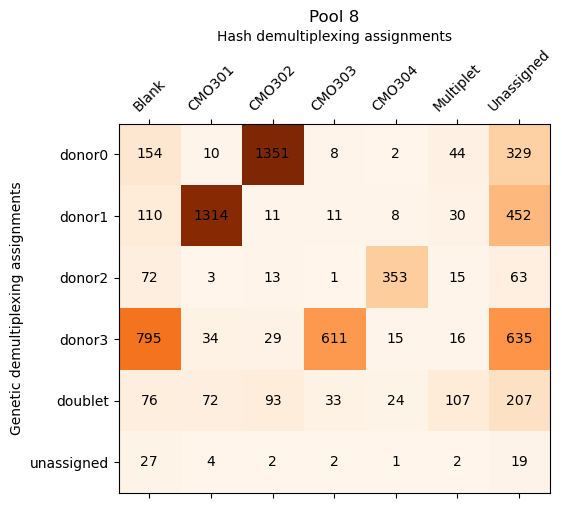

In [210]:
fig, ax = plt.subplots()
ax.matshow(pivot_df, cmap="Oranges")

for (i, j), z in np.ndenumerate(pivot_df):
    ax.text(j, i, "{:.0f}".format(z), ha="center", va="center")


ax.set_xticks(np.arange(len(pivot_df.columns)))
ax.set_yticks(np.arange(len(pivot_df.index)))
ax.set_xticklabels(pivot_df.columns, rotation=45)
ax.set_yticklabels(pivot_df.index)
ax.xaxis.set_label_position("top")
ax.set_xlabel("Hash demultiplexing assignments")
ax.set_ylabel("Genetic demultiplexing assignments")
ax.set_title(f"Pool {pool}")


In [211]:
fig.savefig(f"plots/demultiplexing_assignments_pool{pool}.pdf", bbox_inches="tight")
